Suba un archivo de texto (.txt). Si no sube nada (cancel), se usará el Quijote por defecto.


Procesando archivo: pg2000.txt
Se escribieron los pares (términos procesados, términos únicos) en 'heaps_law_data.csv'
Cantidad total de términos procesados: 357089
Cantidad total de términos únicos: 23089

Verificando la Ley de Heaps...
Parámetros óptimos encontrados:
  K = 13.1325
  beta = 0.5832


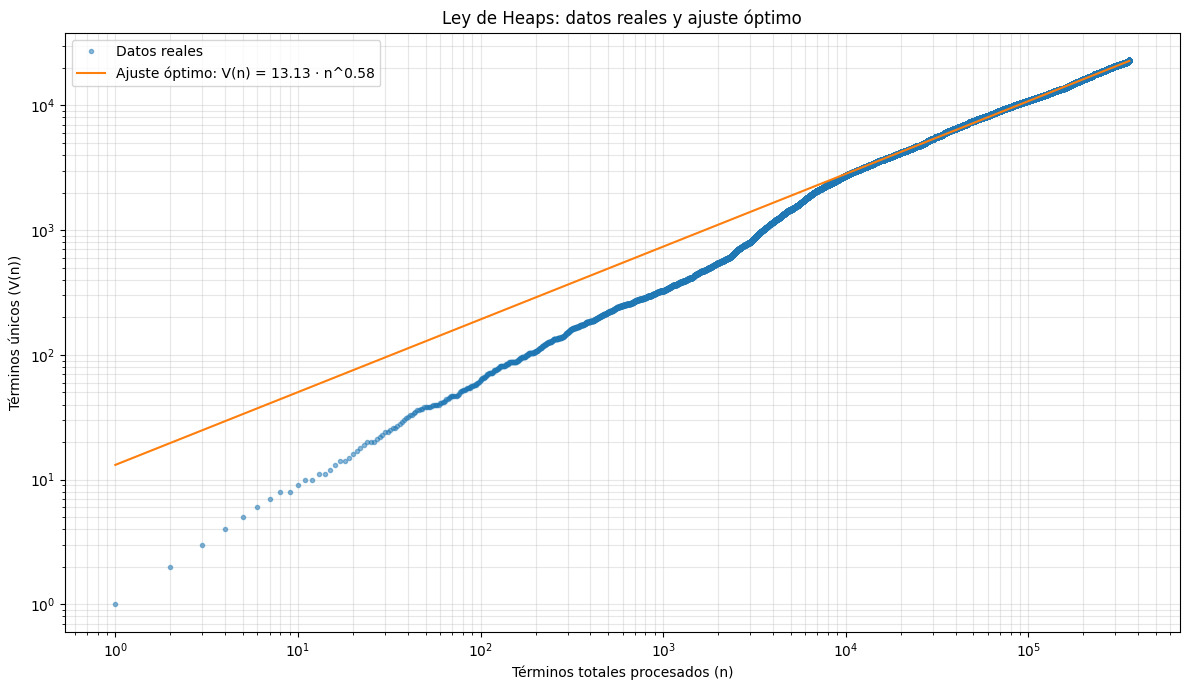

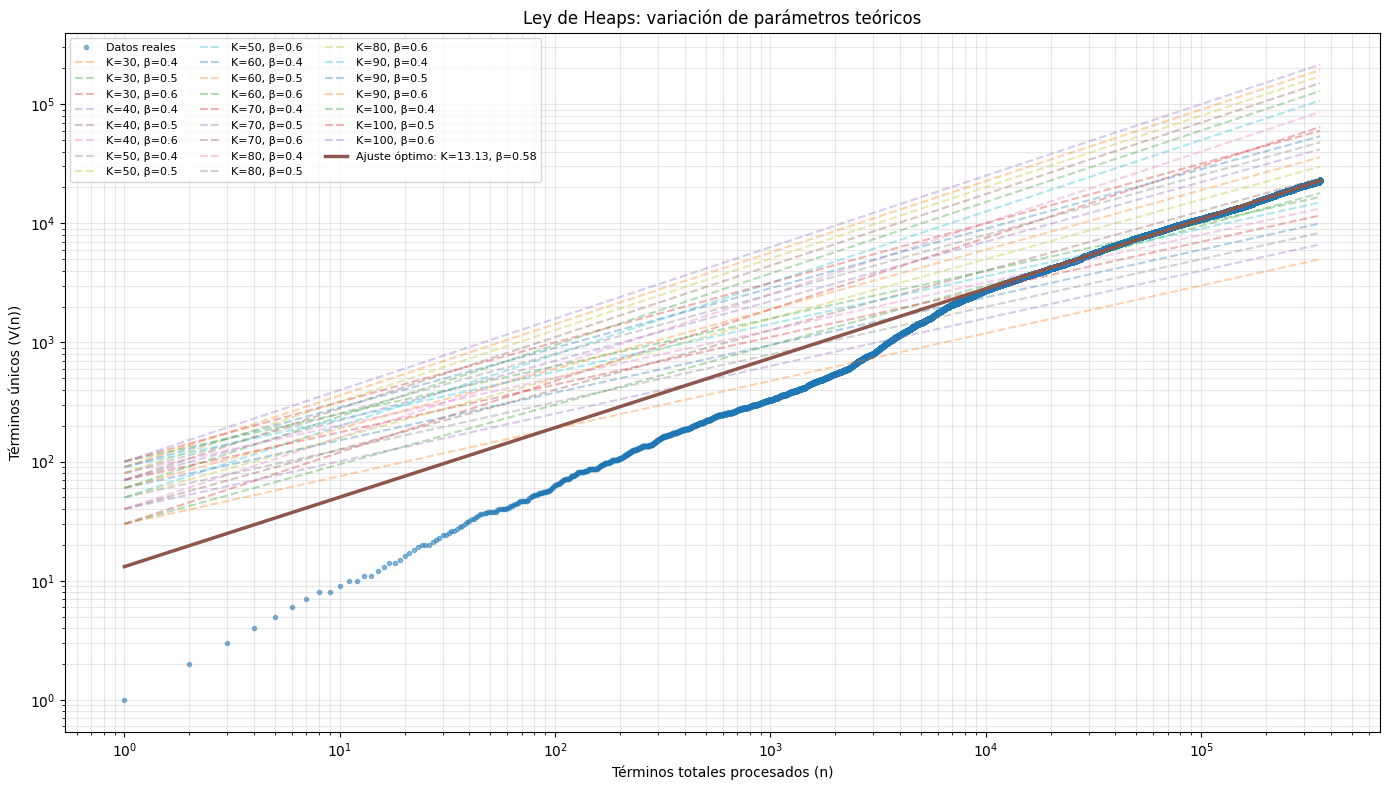

In [2]:
import os
import sys
import re
import unicodedata
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score
from google.colab import files

# PARÁMETROS GENERALES
MAX_SIZE = 30
MIN_SIZE = 2


def translate(string):
    """
    Convierte caracteres acentuados a su forma no acentuada.
    """
    return (
        unicodedata.normalize("NFD", string)
        .encode("ascii", "ignore")
        .decode("ascii")
    )


def tokenize(text):
    """
    Tokeniza el texto extrayendo palabras formadas por letras,
    permitiendo guiones y apóstrofes internos.
    """
    text = text.lower()
    text = translate(text)
    word_re = re.compile(r"[a-z]+(?:[-'][a-z]+)*")
    return word_re.findall(text)


def calculate_heaps_data(tokens_doc, min_size=2, max_size=30):
    """
    Calcula los pares:
    (#términos totales procesados, #términos únicos)

    No elimina stopwords.
    """
    processed_tokens_count = []
    unique_terms_count = []

    current_unique_terms = set()
    current_token_count = 0

    for token in tokens_doc:
        if len(token) < min_size or len(token) > max_size:
            continue

        current_token_count += 1
        current_unique_terms.add(token)

        processed_tokens_count.append(current_token_count)
        unique_terms_count.append(len(current_unique_terms))

    return processed_tokens_count, unique_terms_count


def heaps_law_func(n, K, beta):
    """
    Función de la Ley de Heaps:
    V(n) = K * n^beta
    """
    return K * (n ** beta)


def save_in_file(output_filename, n_values, V_values):
    """
    Escribe a archivo los pares:
    (términos totales procesados, términos únicos)
    """
    with open(output_filename, "w", encoding="utf-8") as f:
        f.write("terminos_totales_procesados,terminos_unicos\n")
        for n, V in zip(n_values, V_values):
            f.write(f"{n},{V}\n")


def process_file(input_filename):
    """
    Procesa el archivo, calcula pares para Heaps y devuelve los datos.
    """
    try:
        with open(input_filename, "r", encoding="utf-8", errors="ignore") as file_handle:
            raw_text = file_handle.read()
    except FileNotFoundError:
        print(f"Error: no se encontró el archivo '{input_filename}'.")
        sys.exit(1)
    except Exception as e:
        print(f"Error al leer el archivo '{input_filename}': {e}")
        sys.exit(1)

    tokens = tokenize(raw_text)
    n_values, V_values = calculate_heaps_data(tokens, min_size=MIN_SIZE, max_size=MAX_SIZE)

    if not n_values:
        print("No se encontraron tokens válidos luego del filtrado por longitud.")
        sys.exit(1)

    return np.array(n_values), np.array(V_values)


def graph_heaps(n_array, V_array):
    """
    Grafica:
    1. Datos reales + ajuste óptimo
    2. Datos reales + curvas teóricas variando K y beta + ajuste óptimo
    """
    print("\nVerificando la Ley de Heaps...")

    # Ajuste óptimo
    try:
        popt, _ = curve_fit(
            heaps_law_func,
            n_array,
            V_array,
            p0=[50, 0.5],
            maxfev=10000
        )
        K_opt, beta_opt = popt

        print("Parámetros óptimos encontrados:")
        print(f"  K = {K_opt:.4f}")
        print(f"  beta = {beta_opt:.4f}")

        V_pred = heaps_law_func(n_array, K_opt, beta_opt)
        r2 = r2_score(V_array, V_pred)

        n_fit_range = np.linspace(n_array.min(), n_array.max(), 1000)
        V_fit_curve = heaps_law_func(n_fit_range, K_opt, beta_opt)

    except RuntimeError as e:
        print(f"No se pudo ajustar la curva de Heaps: {e}")
        K_opt, beta_opt, r2 = None, None, None
        n_fit_range = np.linspace(n_array.min(), n_array.max(), 1000)
        V_fit_curve = None

    # ---------------------------------------------------------
    # Gráfico 1: datos reales + ajuste óptimo
    # ---------------------------------------------------------
    plt.figure(figsize=(12, 7))
    plt.plot(
        n_array,
        V_array,
        'o',
        label='Datos reales',
        markersize=3,
        alpha=0.5
    )

    if V_fit_curve is not None:
        plt.plot(
            n_fit_range,
            V_fit_curve,
            label=f'Ajuste óptimo: V(n) = {K_opt:.2f} · n^{beta_opt:.2f}'
        )

    plt.xscale('log')
    plt.yscale('log')
    plt.title('Ley de Heaps: datos reales y ajuste óptimo')
    plt.xlabel('Términos totales procesados (n)')
    plt.ylabel('Términos únicos (V(n))')
    plt.legend()
    plt.grid(True, which='both', alpha=0.3)
    plt.tight_layout()
    plt.show()

    # ---------------------------------------------------------
    # Gráfico 2: variación de parámetros K y beta
    # ---------------------------------------------------------
    plt.figure(figsize=(14, 8))

    plt.plot(
        n_array,
        V_array,
        'o',
        label='Datos reales',
        markersize=3,
        alpha=0.5
    )

    K_values = range(30, 101, 10)       # 30, 40, ..., 100
    beta_values = np.arange(0.4, 0.61, 0.1)  # 0.4, 0.5, 0.6

    for K in K_values:
        for beta in beta_values:
            V_teorico = heaps_law_func(n_fit_range, K, beta)
            plt.plot(
                n_fit_range,
                V_teorico,
                linestyle='--',
                alpha=0.35,
                label=f'K={K}, β={beta:.1f}'
            )

    if V_fit_curve is not None:
        plt.plot(
            n_fit_range,
            V_fit_curve,
            linewidth=2.5,
            label=f'Ajuste óptimo: K={K_opt:.2f}, β={beta_opt:.2f}'
        )

    plt.xscale('log')
    plt.yscale('log')
    plt.title('Ley de Heaps: variación de parámetros teóricos')
    plt.xlabel('Términos totales procesados (n)')
    plt.ylabel('Términos únicos (V(n))')
    plt.legend(fontsize=8, ncol=3)
    plt.grid(True, which='both', alpha=0.3)
    plt.tight_layout()
    plt.show()


def main():
    """
    Programa que verifica la ley de Heaps dado un archivo de texto subido.
    Si no se pasa parámetro, usa 'pg2000.txt' por defecto.
    """

    print("Suba un archivo de texto (.txt). Si no sube nada (cancel), se usará el Quijote por defecto.")

    uploaded = files.upload()

    if uploaded:
        input_filename = list(uploaded.keys())[0]
        print(f"Archivo cargado: {input_filename}")
    else:
      # Descarga archivo por defecto si no existe
      input_filename = "pg2000.txt"
      if not os.path.exists(input_filename):
          print(f"Descargando {input_filename}...")
          !rm -f pg2000.txt
          !wget -q http://www.gutenberg.org/cache/epub/2000/pg2000.txt
          if not os.path.exists(input_filename):
              print(f"Error: No se pudo descargar {input_filename}. Por favor, verifique la URL o proporcione un archivo local.")
              sys.exit(1)

    print(f"Procesando archivo: {input_filename}")

    n_array, V_array = process_file(input_filename)

    output_filename = "heaps_law_data.csv"
    save_in_file(output_filename, n_array, V_array)

    print(f"Se escribieron los pares (términos procesados, términos únicos) en '{output_filename}'")
    print(f"Cantidad total de términos procesados: {n_array[-1]}")
    print(f"Cantidad total de términos únicos: {V_array[-1]}")

    graph_heaps(n_array, V_array)


if __name__ == "__main__":
    main()